# Simulation experiments

In this notebook we briefly go through the synthetic data experiment that demonstrates the difference between CMF and PARAFAC2 (Figure S.16).

#### Requirements

We recommend creating a fresh python environment and installing the required libraries via
```
pip install -r requirements.txt
```

### 0. Imports

In [3]:
import numpy as np
import tensorly as tl
import pandas as pd
import tqdm.notebook as tqdm
import matplotlib.pyplot as plt

from tensorly.decomposition import non_negative_parafac

import matcouply
from matcouply.decomposition import cmf_aoadmm, initialize_cmf
from matcouply.penalties import NonNegativity, Parafac2
from tensorly.decomposition import non_negative_parafac
from tensorly.cp_tensor import cp_to_tensor
from tensorly.metrics import congruence_coefficient

from copy import deepcopy
import plot_funcs

### 1. Synthetic data generation

In [ ]:
I = 10   # features
J = 12   # time points  (discrete indices 0 … 11)
K = 10   # subjects
R = 2    # components

rng = np.random.RandomState(27)

A = rng.uniform(0, 1, (I, R))
C = rng.uniform(0.5, 1.0, (K, R))

# Early peakers: peak index in {0,1,2,3,4}      (< 5)
# Late  peakers: peak index in {8,9,10,11}      (> 7)
# Indices 5,6,7 form a gap, making early/late groups clearly separated.
#
# Component 0 — 50 / 50:  subjects 0-4  early,  subjects 5-9  late
# Component 1 — 30 / 70:  subjects 0-2  early,  subjects 3-9  late

time_idx   = np.arange(J, dtype=float)
bell_width = 1.5                   # Gaussian std in time-index units
baseline   = 0.2                   # floor so no bell value is near zero
early_pool = list(range(5))        # {0,1,2,3,4}
late_pool  = list(range(8, J))     # {8,9,10,11}
n_early    = {0: 5, 1: 3}         # number of early-peaker subjects per component

peaks = np.zeros((K, R), dtype=int)
B = []
for k in range(K):
    B_k = np.zeros((J, R))
    for r in range(R):
        pool        = early_pool if k < n_early[r] else late_pool
        peak        = rng.choice(pool)
        peaks[k, r] = peak
        B_k[:, r]  = np.exp(-0.5 * ((time_idx - peak) / bell_width) ** 2) + baseline
    B.append(B_k)

# Tensor: X[:, :, k] = A @ diag(C[k, :]) @ B[k].T
X = np.zeros((I, J, K))
for k in range(K):
    X[:, :, k] = A @ np.diag(C[k, :]) @ B[k].T

# Group masks for plotting (used by plot_factors)
# subject_groups[r] = {'Early': [subject indices], 'Late': [subject indices]}
subject_groups = [
    {'Early': list(range(n_early[r])), 'Late': list(range(n_early[r], K))}
    for r in range(R)
]

print(f"X shape : {X.shape}  (I={I}, J={J}, K={K}, R={R})")
print(f"Non-negative : {(X >= 0).all()},  B min : {min(b.min() for b in B):.3f}")
print(f"\nPeak indices per subject:")
print(f"  {'subject':>8}  {'comp 0':>10}  {'comp 1':>10}")
for k in range(K):
    tag0 = 'Early' if peaks[k, 0] < 5 else 'Late'
    tag1 = 'Early' if peaks[k, 1] < 5 else 'Late'
    print(f"  {k:>8}  {peaks[k,0]:>4} ({tag0})  {peaks[k,1]:>4} ({tag1})")

# PARAFAC2 constraint violation
def parafac2_violation(B):
    Phi      = B[0].T @ B[0]
    Phi_norm = np.linalg.norm(Phi)
    abs_devs = np.array([np.linalg.norm(b.T @ b - Phi) for b in B])
    rel_devs = abs_devs / (Phi_norm + 1e-12)
    return abs_devs, rel_devs

abs_devs, rel_devs = parafac2_violation(B)
print(f"\nPARAFAC2 constraint violation  ||B_k^T B_k - Phi||_F")
print(f"  absolute : mean={abs_devs.mean():.4f}  max={abs_devs.max():.4f}")
print(f"  relative : mean={rel_devs.mean():.4f}  max={rel_devs.max():.4f}")

X shape : (10, 12, 10)  (I=10, J=12, K=10, R=2)
Non-negative : True,  B min : 0.200

Peak indices per subject:
   subject      comp 0      comp 1
         0     2 (Early)     4 (Early)
         1     3 (Early)     0 (Early)
         2     3 (Early)     1 (Early)
         3     1 (Early)     8 (Late)
         4     1 (Early)     9 (Late)
         5    10 (Late)    11 (Late)
         6    10 (Late)    10 (Late)
         7    10 (Late)     9 (Late)
         8    10 (Late)     9 (Late)
         9     8 (Late)    11 (Late)

PARAFAC2 constraint violation  ||B_k^T B_k - Phi||_F
  absolute : mean=1.3494  max=2.5925
  relative : mean=0.1625  max=0.3121


In [7]:
from plot_funcs import get_profiles_factors

SUBJECT_COLORS = plt.cm.tab10(np.arange(10) / 10)
GROUP_COLORS   = {'Early': 'tab:blue', 'Late': 'tab:orange'}


def plot_factors(factors, feature_labels=None, time_labels=None, subject_labels=None,
                 subject_groups=None, profile_ylims=None, figsize_per_row=(12, 3)):
    """Plot feature loadings (bar) and scaled time profiles.

    Parameters
    ----------
    factors        : (A, B, D) tuple
    subject_groups : list of R dicts, each mapping group_name → [subject indices].
                     When provided, plots group mean ± SEM instead of individual lines.
    profile_ylims  : list of R (ymin, ymax) tuples for the time-profile axes.
                     If None, limits are derived from the scaled profiles and returned.

    Returns
    -------
    ylims : list of R (ymin, ymax) tuples (the limits actually applied)
    """
    A_sc, B2plot, D_sc = get_profiles_factors(deepcopy(factors))

    R = A_sc.shape[1]
    I = A_sc.shape[0]
    K = len(B2plot)
    J = B2plot[0].shape[0]
    x = np.arange(J)

    subj_labels = subject_labels if subject_labels is not None else [f'Subject {k}' for k in range(K)]

    # Compute ylims from the scaled profiles (all subjects, add 5% margin)
    computed_ylims = []
    for r in range(R):
        vals = np.concatenate([B2plot[k][:, r] for k in range(K)])
        lo, hi = vals.min(), vals.max()
        margin = 0.05 * (hi - lo) if hi > lo else 0.1
        computed_ylims.append((lo - margin, hi + margin))

    ylims = profile_ylims if profile_ylims is not None else computed_ylims

    fig, axes = plt.subplots(R, 2, figsize=(figsize_per_row[0], figsize_per_row[1] * R))
    if R == 1:
        axes = axes[np.newaxis, :]

    for r in range(R):

        # ── Left: feature loadings ────────────────────────────────────────────
        ax = axes[r, 0]
        ax.bar(np.arange(I), A_sc[:, r], color='steelblue', alpha=0.85)
        ax.set_title(f'Component {r + 1}  —  feature loadings', fontsize=10)
        ax.set_xlabel('Feature')
        ax.set_ylabel('Loading')
        ax.grid(axis='y', alpha=0.3)
        if feature_labels is not None:
            ax.set_xticks(np.arange(I))
            ax.set_xticklabels(feature_labels, rotation=45, ha='right', fontsize=7)

        # ── Right: time profiles ──────────────────────────────────────────────
        ax = axes[r, 1]

        if subject_groups is not None:
            for gname, gidx in subject_groups[r].items():
                color  = GROUP_COLORS.get(gname, 'tab:gray')
                stack  = np.stack([B2plot[k][:, r] for k in gidx], axis=0).astype(float)
                center = np.nanmean(stack, axis=0)
                sd     = np.nanstd(stack, axis=0, ddof=1)
                sem    = sd / np.sqrt(len(gidx))
                ax.fill_between(x, center - sem, center + sem,
                                alpha=0.25, color=color, linewidth=0)
                ax.plot(x, center, label=gname, color=color, linewidth=2.5, alpha=0.9)
        else:
            for k in range(K):
                ax.plot(B2plot[k][:, r], color=SUBJECT_COLORS[k], label=subj_labels[k])

        ax.set_ylim(ylims[r])
        ax.axhline(0, color='k', linewidth=0.6, linestyle='--')
        ax.set_title(f'Component {r + 1}  —  scaled time profiles', fontsize=10)
        ax.set_xlabel('Time point')
        ax.set_ylabel('Amplitude')
        ax.legend(fontsize=8, loc='best')
        ax.grid(alpha=0.3)
        if time_labels is not None:
            ax.set_xticks(x)
            ax.set_xticklabels(time_labels, rotation=45, ha='right', fontsize=7)

    plt.tight_layout()
    plt.show()

    return computed_ylims

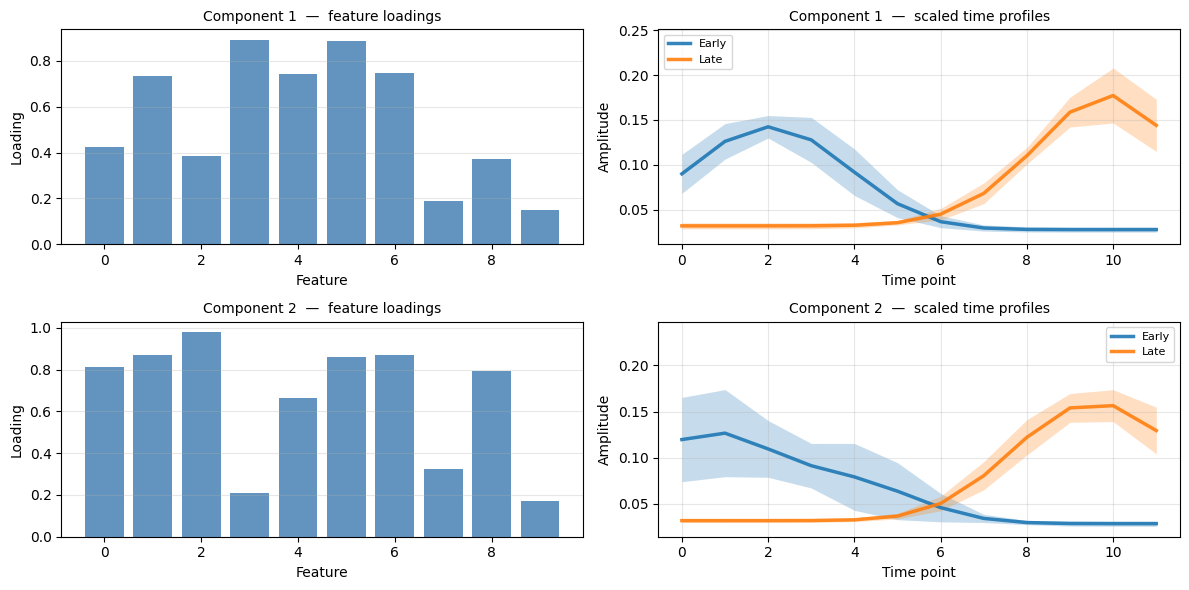

In [8]:
gt_ylims = plot_factors((A, B, C), subject_groups=subject_groups)

### 2. Fit models

  init  0  rec_err=0.048598  converged
  init  1  rec_err=0.048599  converged
  init  2  rec_err=0.048598  converged
  init  3  rec_err=0.048598  converged
  init  4  rec_err=0.048598  converged
  init  5  rec_err=0.050270  converged
  init  6  rec_err=0.051641  converged
  init  7  rec_err=0.050267  converged
  init  8  rec_err=0.048598  converged
  init  9  rec_err=0.048598  converged

Best reconstruction error: 0.048598


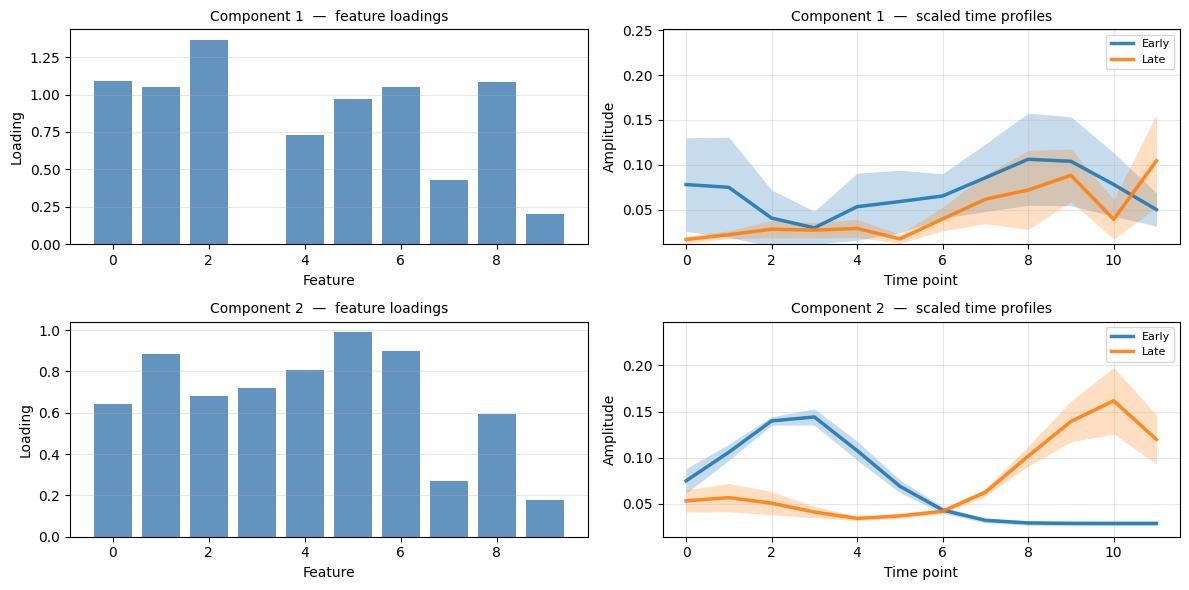

[(np.float64(-0.014468962281396354), np.float64(0.30375360881682173)),
 (np.float64(0.00947357184935723), np.float64(0.30854620611994044))]

In [9]:
N_INITS = 10
N_ITER  = 6000

X_fit = X.transpose(2, 1, 0)            # (K, J, I)
X_fit = X_fit / np.linalg.norm(X_fit)

best_err  = np.inf
best_facs = None

for init in range(N_INITS):
    (weights, (D_out, B_out, A_out)), diag = cmf_aoadmm(
        matrices=X_fit,
        rank=R,
        return_errors=True,
        n_iter_max=N_ITER,
        regs=[[NonNegativity()], [Parafac2(), NonNegativity()], [NonNegativity()]],
        tol=1e-6,
        feasibility_penalty_scale=1,
        inner_n_iter_max=20,
        absolute_tol=1e-6,
        feasibility_tol=1e-5,
        inner_tol=1e-5,
        random_state=init,
    )

    err = diag.rec_errors[-1]
    converged = len(diag.regularized_loss) < N_ITER - 10
    print(f"  init {init:2d}  rec_err={err:.6f}  "
          f"{'converged' if converged else f'hit iter limit ({len(diag.rec_errors)} iters)'}")

    if err < best_err:
        best_err  = err
        best_facs = (A_out, B_out, D_out)

print(f"\nBest reconstruction error: {best_err:.6f}")
plot_factors(best_facs, subject_groups=subject_groups, profile_ylims=gt_ylims)

  init  0  rec_err=0.001379  converged
  init  1  rec_err=0.001377  converged
  init  2  rec_err=0.001409  converged
  init  3  rec_err=0.001220  converged
  init  4  rec_err=0.001414  converged
  init  5  rec_err=0.001075  converged
  init  6  rec_err=0.000769  converged
  init  7  rec_err=0.000580  converged
  init  8  rec_err=0.001388  converged
  init  9  rec_err=0.001402  converged

Best reconstruction error (CMF): 0.000580


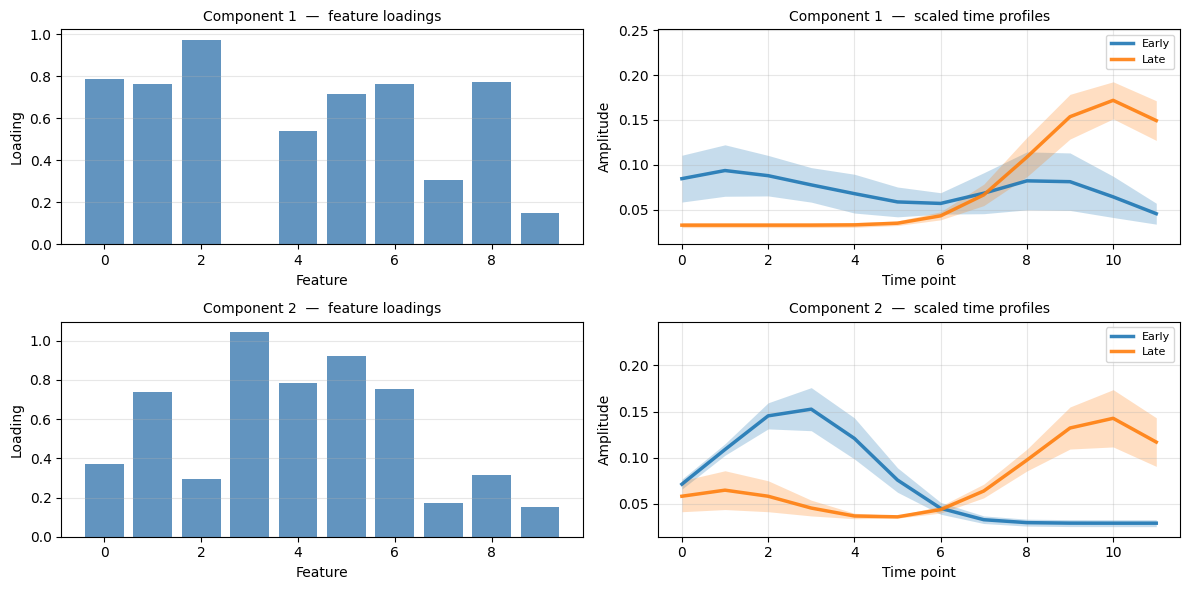

[(np.float64(0.01236777935045027), np.float64(0.2512957717525379)),
 (np.float64(0.012695902035424804), np.float64(0.25649931203362597))]

In [11]:
N_INITS = 10
N_ITER  = 6000

X_fit = X.transpose(2, 1, 0)            # (K, J, I)
X_fit = X_fit / np.linalg.norm(X_fit)

best_err_cmf  = np.inf
best_facs_cmf = None

for init in range(N_INITS):
    weights, (A_init, B_init, D_init) = initialize_cmf(
        matrices=X_fit,
        rank=R,
        init="random",
        svd_fun="truncated_svd",
        random_state=init,
    )
    A_init   = np.ones_like(A_init)
    cmf_init = weights, (A_init, B_init, D_init)

    (weights, (D_out, B_out, A_out)), diag = cmf_aoadmm(
        matrices=X_fit,
        rank=R,
        return_errors=True,
        n_iter_max=N_ITER,
        regs=[[NonNegativity()], [NonNegativity()], [NonNegativity()]],
        tol=1e-6,
        init=cmf_init,
        update_A=False,
        inner_n_iter_max=20,
        absolute_tol=1e-6,
        feasibility_tol=1e-5,
        inner_tol=1e-5,
        random_state=init,
    )

    err = diag.rec_errors[-1]
    converged = len(diag.regularized_loss) < N_ITER - 10
    print(f"  init {init:2d}  rec_err={err:.6f}  "
          f"{'converged' if converged else f'hit iter limit ({len(diag.rec_errors)} iters)'}")

    if err < best_err_cmf:
        best_err_cmf  = err
        best_facs_cmf = (A_out, B_out, D_out)

print(f"\nBest reconstruction error (CMF): {best_err_cmf:.6f}")
plot_factors(best_facs_cmf, subject_groups=subject_groups, profile_ylims=gt_ylims)

### 4. Model comparison

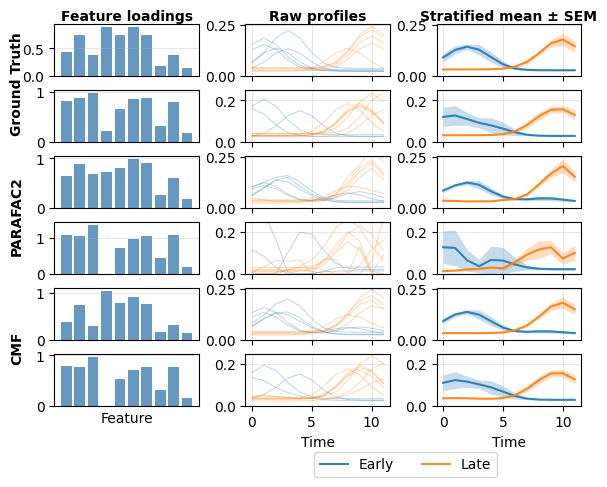

In [28]:
# ── Summary grid: (n_models × R) rows  ×  3 cols ─────────────────────────────
from matplotlib.lines import Line2D
from scipy.optimize import linear_sum_assignment

models_to_plot = [
    ('Ground Truth', (A, B, C)),
    ('PARAFAC2',     best_facs),
    ('CMF',          best_facs_cmf),
]
n_models   = len(models_to_plot)
col_titles = ['Feature loadings', 'Raw profiles', 'Stratified mean ± SEM']
nrows      = n_models * R   # 6

# Ground-truth scaled feature loadings used for alignment
A_gt_sc, _, _ = get_profiles_factors(deepcopy((A, B, C)))

def align_components(A_sc, A_gt_sc):
    """Return permutation that best matches A_sc columns to A_gt_sc columns
    by cosine similarity (Hungarian algorithm)."""
    def col_norm(M):
        return M / (np.linalg.norm(M, axis=0, keepdims=True) + 1e-12)
    sim = col_norm(A_sc).T @ col_norm(A_gt_sc)   # (R, R) cosine similarities
    row_ind, col_ind = linear_sum_assignment(-np.abs(sim))
    perm = np.empty(R, dtype=int)
    perm[col_ind] = row_ind                        # map gt_r → fitted_r
    return perm

fig, axes = plt.subplots(nrows, 3,
    figsize=(6.759, 0.68 * 6.759),
    constrained_layout=False)
fig.subplots_adjust(left=0.18, right=0.96, bottom=0.12, top=0.95,
                    wspace=0.32, hspace=0.28)

profile_ylims = [(0, hi) for (_, hi) in gt_ylims]

for mi, (mname, facs) in enumerate(models_to_plot):
    A_sc, B2plot, _ = get_profiles_factors(deepcopy(facs))

    # Align fitted components to GT order by cosine similarity of A columns
    perm = align_components(A_sc, A_gt_sc)
    A_sc   = A_sc[:, perm]
    B2plot = [b[:, perm] for b in B2plot]

    for r in range(R):
        row       = mi * R + r
        is_first  = (mi == 0 and r == 0)
        new_model = (r == 0)
        last_row  = (mi == n_models - 1 and r == R - 1)
        t_pad     = 8 if (mi > 0 and r == 0) else 3

        # ── Col 0: Feature loadings ───────────────────────────────────────
        ax = axes[row, 0]
        ax.bar(np.arange(I), A_sc[:, r], color='steelblue', alpha=0.82)
        ax.grid(axis='y', alpha=0.3)
        ax.set_xticks([])
        if last_row:
            ax.set_xlabel('Feature')
        else:
            ax.tick_params(bottom=False, labelbottom=False)
        if is_first:
            ax.set_title(col_titles[0], fontweight='bold', pad=t_pad,fontsize=10)
        elif new_model:
            ax.set_title('', pad=t_pad)

        # ── Col 1: Raw profiles colored by group ──────────────────────────
        ax = axes[row, 1]
        for k in range(K):
            gname = 'Early' if k < n_early[r] else 'Late'
            ax.plot(B2plot[k][:, r], color=GROUP_COLORS[gname],
                    alpha=0.3, linewidth=0.7)
        ax.set_ylim(profile_ylims[r])
        ax.grid(alpha=0.3)
        if last_row:
            ax.set_xlabel('Time')
        else:
            ax.tick_params(labelbottom=False)
        if is_first:
            ax.set_title(col_titles[1], fontweight='bold', pad=t_pad,fontsize=10)
        elif new_model:
            ax.set_title('', pad=t_pad)

        # ── Col 2: Stratified mean ± SEM ─────────────────────────────────
        ax = axes[row, 2]
        for gname, gidx in subject_groups[r].items():
            color  = GROUP_COLORS[gname]
            stack  = np.stack([B2plot[k][:, r] for k in gidx]).astype(float)
            center = np.nanmean(stack, axis=0)
            sem    = np.nanstd(stack, axis=0, ddof=1) / np.sqrt(len(gidx))
            xv     = np.arange(J)
            ax.fill_between(xv, center - sem, center + sem,
                            alpha=0.25, color=color, linewidth=0)
            ax.plot(xv, center, label=gname, color=color,
                    alpha=0.9, linewidth=1.5)
        ax.set_ylim(profile_ylims[r])
        ax.grid(alpha=0.3)
        if last_row:
            ax.set_xlabel('Time')
        else:
            ax.tick_params(labelbottom=False)
        if is_first:
            ax.set_title(col_titles[2], fontweight='bold', pad=t_pad,fontsize=10)
        elif new_model:
            ax.set_title('', pad=t_pad)

# Vertically centred model name labelS
for mi, (mname, _) in enumerate(models_to_plot):
    ax_top = axes[mi * R,         0]
    ax_bot = axes[mi * R + R - 1, 0]
    y_mid  = (ax_bot.get_position().y0 + ax_top.get_position().y1) / 2
    fig.text(0.125, y_mid, mname,
             ha='center', va='center', fontweight='bold', rotation=90,fontsize=10)

# Single legend below all subplots 
leg_handles = [
    Line2D([0], [0], color=GROUP_COLORS['Early'], alpha=0.9, linewidth=1.5, label='Early'),
    Line2D([0], [0], color=GROUP_COLORS['Late'],  alpha=0.9, linewidth=1.5, label='Late'),
]
fig.legend(handles=leg_handles, loc='lower center',
           bbox_to_anchor=(0.7, -0.05), ncols=2)

plt.show()